## Data Exploration

In [173]:
import pandas as pd

xls_file = pd.ExcelFile('drug.xlsx')
sheet_dict = {}
for sheet_name in xls_file.sheet_names:
    sheet_dict[sheet_name] = pd.read_excel(xls_file, sheet_name=sheet_name)

drug_test = sheet_dict['Drug_Test']
drug_train = sheet_dict['Drug_Train']
drug_unseen = sheet_dict['Drug_Unseen']


In [174]:
drug_train

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG
0,1,23,F,HIGH,HIGH,0.792535,0.031258,drugY
1,2,47,M,LOW,HIGH,0.739309,0.056468,drugC
2,3,47,M,LOW,HIGH,0.697269,0.068944,drugC
3,4,28,F,NORMAL,HIGH,0.563682,0.072289,drugX
4,5,61,F,LOW,HIGH,0.559294,0.030998,drugY
...,...,...,...,...,...,...,...,...
195,196,56,F,LOW,HIGH,0.848774,0.073380,drugC
196,197,16,M,LOW,HIGH,0.743021,0.061886,drugC
197,198,52,M,NORMAL,HIGH,0.549945,0.055581,drugX
198,199,23,M,NORMAL,NORMAL,0.784520,0.055959,drugX


In [175]:
drug_test

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG
0,21,57,M,LOW,NORMAL,0.536746,0.028061,drugY
1,28,49,F,NORMAL,NORMAL,0.694689,0.074055,drugX
2,32,74,M,HIGH,HIGH,0.715337,0.074773,drugB
3,33,49,M,LOW,NORMAL,0.625889,0.056828,drugX
4,34,65,F,HIGH,NORMAL,0.828898,0.026004,drugY
5,35,53,M,NORMAL,HIGH,0.644936,0.045632,drugX
6,37,32,M,HIGH,NORMAL,0.529750,0.056087,drugA
7,48,68,M,LOW,HIGH,0.726677,0.070616,drugC
8,55,68,F,HIGH,NORMAL,0.775410,0.076100,drugB
9,56,26,F,LOW,HIGH,0.578002,0.040819,drugC


In [176]:
drug_unseen

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG
0,21,57,M,LOW,NORMAL,0.536746,0.028061,NaN
1,28,49,F,NORMAL,NORMAL,0.694689,0.074055,NaN
2,32,74,M,HIGH,HIGH,0.715337,0.074773,NaN
3,33,49,M,LOW,NORMAL,0.625889,0.056828,NaN
4,34,65,F,HIGH,NORMAL,0.828898,0.026004,NaN
5,35,53,M,NORMAL,HIGH,0.644936,0.045632,NaN
6,37,32,M,HIGH,NORMAL,0.529750,0.056087,NaN
7,48,68,M,LOW,HIGH,0.726677,0.070616,NaN
8,55,68,F,HIGH,NORMAL,0.775410,0.076100,NaN
9,56,26,F,LOW,HIGH,0.578002,0.040819,NaN


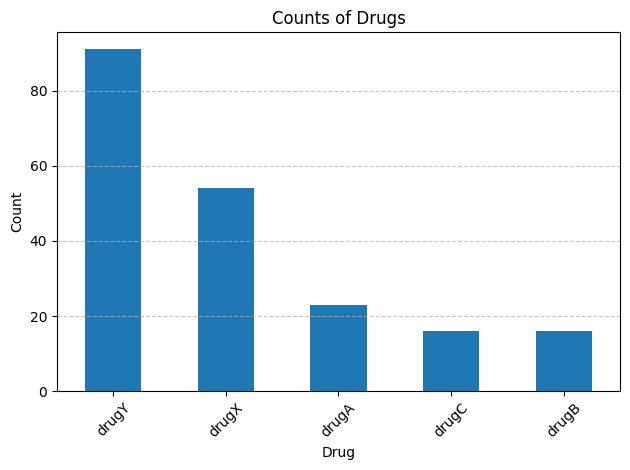

In [177]:
import matplotlib.pyplot as plt
drug_counts = drug_train['DRUG'].value_counts()


drug_counts.plot(kind='bar')
plt.title('Counts of Drugs')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Preprocessing


### NA_to_K and drop NA and K

In [178]:
drug_test['NA_to_K'] = drug_test['NA']/drug_test['K']
drug_train['NA_to_K'] = drug_train['NA']/drug_train['K']
drug_unseen['NA_to_K'] = drug_unseen['NA']/drug_unseen['K']



In [179]:
drug_test

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG,NA_to_K
0,21,57,M,LOW,NORMAL,0.536746,0.028061,drugY,19.127829
1,28,49,F,NORMAL,NORMAL,0.694689,0.074055,drugX,9.380717
2,32,74,M,HIGH,HIGH,0.715337,0.074773,drugB,9.566782
3,33,49,M,LOW,NORMAL,0.625889,0.056828,drugX,11.013743
4,34,65,F,HIGH,NORMAL,0.828898,0.026004,drugY,31.875788
5,35,53,M,NORMAL,HIGH,0.644936,0.045632,drugX,14.133415
6,37,32,M,HIGH,NORMAL,0.529750,0.056087,drugA,9.445148
7,48,68,M,LOW,HIGH,0.726677,0.070616,drugC,10.290543
8,55,68,F,HIGH,NORMAL,0.775410,0.076100,drugB,10.189356
9,56,26,F,LOW,HIGH,0.578002,0.040819,drugC,14.160122


In [180]:
drug_train

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG,NA_to_K
0,1,23,F,HIGH,HIGH,0.792535,0.031258,drugY,25.354629
1,2,47,M,LOW,HIGH,0.739309,0.056468,drugC,13.092530
2,3,47,M,LOW,HIGH,0.697269,0.068944,drugC,10.113556
3,4,28,F,NORMAL,HIGH,0.563682,0.072289,drugX,7.797618
4,5,61,F,LOW,HIGH,0.559294,0.030998,drugY,18.042906
...,...,...,...,...,...,...,...,...,...
195,196,56,F,LOW,HIGH,0.848774,0.073380,drugC,11.566830
196,197,16,M,LOW,HIGH,0.743021,0.061886,drugC,12.006286
197,198,52,M,NORMAL,HIGH,0.549945,0.055581,drugX,9.894478
198,199,23,M,NORMAL,NORMAL,0.784520,0.055959,drugX,14.019550


In [181]:
drug_unseen

,ID,AGE,SEX,BP,CHOLES,NA,K,DRUG,NA_to_K
0,21,57,M,LOW,NORMAL,0.536746,0.028061,NaN,19.127829
1,28,49,F,NORMAL,NORMAL,0.694689,0.074055,NaN,9.380717
2,32,74,M,HIGH,HIGH,0.715337,0.074773,NaN,9.566782
3,33,49,M,LOW,NORMAL,0.625889,0.056828,NaN,11.013743
4,34,65,F,HIGH,NORMAL,0.828898,0.026004,NaN,31.875788
5,35,53,M,NORMAL,HIGH,0.644936,0.045632,NaN,14.133415
6,37,32,M,HIGH,NORMAL,0.529750,0.056087,NaN,9.445148
7,48,68,M,LOW,HIGH,0.726677,0.070616,NaN,10.290543
8,55,68,F,HIGH,NORMAL,0.775410,0.076100,NaN,10.189356
9,56,26,F,LOW,HIGH,0.578002,0.040819,NaN,14.160122


Borrow this place to drop ID also. Sorry I forget.

In [182]:
drug_train = drug_train.drop(columns=['NA', 'K' , 'ID'])
drug_test = drug_test.drop(columns=['NA', 'K' , 'ID'])
drug_unseen = drug_unseen.drop(columns=['NA', 'K', 'ID'])

In [183]:
drug_train

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,23,F,HIGH,HIGH,drugY,25.354629
1,47,M,LOW,HIGH,drugC,13.092530
2,47,M,LOW,HIGH,drugC,10.113556
3,28,F,NORMAL,HIGH,drugX,7.797618
4,61,F,LOW,HIGH,drugY,18.042906
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,drugC,11.566830
196,16,M,LOW,HIGH,drugC,12.006286
197,52,M,NORMAL,HIGH,drugX,9.894478
198,23,M,NORMAL,NORMAL,drugX,14.019550


In [184]:
drug_test

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,57,M,LOW,NORMAL,drugY,19.127829
1,49,F,NORMAL,NORMAL,drugX,9.380717
2,74,M,HIGH,HIGH,drugB,9.566782
3,49,M,LOW,NORMAL,drugX,11.013743
4,65,F,HIGH,NORMAL,drugY,31.875788
5,53,M,NORMAL,HIGH,drugX,14.133415
6,32,M,HIGH,NORMAL,drugA,9.445148
7,68,M,LOW,HIGH,drugC,10.290543
8,68,F,HIGH,NORMAL,drugB,10.189356
9,26,F,LOW,HIGH,drugC,14.160122


In [185]:
drug_unseen

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,57,M,LOW,NORMAL,NaN,19.127829
1,49,F,NORMAL,NORMAL,NaN,9.380717
2,74,M,HIGH,HIGH,NaN,9.566782
3,49,M,LOW,NORMAL,NaN,11.013743
4,65,F,HIGH,NORMAL,NaN,31.875788
5,53,M,NORMAL,HIGH,NaN,14.133415
6,32,M,HIGH,NORMAL,NaN,9.445148
7,68,M,LOW,HIGH,NaN,10.290543
8,68,F,HIGH,NORMAL,NaN,10.189356
9,26,F,LOW,HIGH,NaN,14.160122


### Discretization

In [186]:
drug_train['NA_to_K'] = pd.cut(drug_train['NA_to_K'], bins=[-float('inf'), 10, 20, 30, 40],labels=['Low', 'Medium', 'High', 'VeryHigh'])
drug_test['NA_to_K'] = pd.cut(drug_test['NA_to_K'], bins=[-float('inf'), 10, 20, 30, 40],labels=['Low', 'Medium', 'High', 'VeryHigh'])
drug_unseen['NA_to_K'] = pd.cut(drug_unseen['NA_to_K'], bins=[-float('inf'), 10, 20, 30, 40],labels=['Low', 'Medium', 'High', 'VeryHigh'])

In [187]:
drug_train

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,23,F,HIGH,HIGH,drugY,High
1,47,M,LOW,HIGH,drugC,Medium
2,47,M,LOW,HIGH,drugC,Medium
3,28,F,NORMAL,HIGH,drugX,Low
4,61,F,LOW,HIGH,drugY,Medium
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,drugC,Medium
196,16,M,LOW,HIGH,drugC,Medium
197,52,M,NORMAL,HIGH,drugX,Low
198,23,M,NORMAL,NORMAL,drugX,Medium


In [188]:
drug_test

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,57,M,LOW,NORMAL,drugY,Medium
1,49,F,NORMAL,NORMAL,drugX,Low
2,74,M,HIGH,HIGH,drugB,Low
3,49,M,LOW,NORMAL,drugX,Medium
4,65,F,HIGH,NORMAL,drugY,VeryHigh
5,53,M,NORMAL,HIGH,drugX,Medium
6,32,M,HIGH,NORMAL,drugA,Low
7,68,M,LOW,HIGH,drugC,Medium
8,68,F,HIGH,NORMAL,drugB,Medium
9,26,F,LOW,HIGH,drugC,Medium


In [189]:
drug_unseen

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,57,M,LOW,NORMAL,NaN,Medium
1,49,F,NORMAL,NORMAL,NaN,Low
2,74,M,HIGH,HIGH,NaN,Low
3,49,M,LOW,NORMAL,NaN,Medium
4,65,F,HIGH,NORMAL,NaN,VeryHigh
5,53,M,NORMAL,HIGH,NaN,Medium
6,32,M,HIGH,NORMAL,NaN,Low
7,68,M,LOW,HIGH,NaN,Medium
8,68,F,HIGH,NORMAL,NaN,Medium
9,26,F,LOW,HIGH,NaN,Medium


### Model construction

#### Just split for use in model only.

In [190]:
drug_train_encoded = pd.get_dummies(drug_train, columns=['SEX','BP','CHOLES','NA_to_K'])

In [191]:
drug_train_encoded

,AGE,DRUG,SEX_F,SEX_M,BP_HIGH,BP_LOW,BP_NORMAL,CHOLES_HIGH,CHOLES_NORMAL,NA_to_K_Low,NA_to_K_Medium,NA_to_K_High,NA_to_K_VeryHigh
0,23,drugY,1,0,1,0,0,1,0,0,0,1,0
1,47,drugC,0,1,0,1,0,1,0,0,1,0,0
2,47,drugC,0,1,0,1,0,1,0,0,1,0,0
3,28,drugX,1,0,0,0,1,1,0,1,0,0,0
4,61,drugY,1,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,56,drugC,1,0,0,1,0,1,0,0,1,0,0
196,16,drugC,0,1,0,1,0,1,0,0,1,0,0
197,52,drugX,0,1,0,0,1,1,0,1,0,0,0
198,23,drugX,0,1,0,0,1,0,1,0,1,0,0


In [192]:
drug_test_encoded = pd.get_dummies(drug_test, columns=['SEX','BP','CHOLES','NA_to_K'])

In [193]:
drug_test_encoded

,AGE,DRUG,SEX_F,SEX_M,BP_HIGH,BP_LOW,BP_NORMAL,CHOLES_HIGH,CHOLES_NORMAL,NA_to_K_Low,NA_to_K_Medium,NA_to_K_High,NA_to_K_VeryHigh
0,57,drugY,0,1,0,1,0,0,1,0,1,0,0
1,49,drugX,1,0,0,0,1,0,1,1,0,0,0
2,74,drugB,0,1,1,0,0,1,0,1,0,0,0
3,49,drugX,0,1,0,1,0,0,1,0,1,0,0
4,65,drugY,1,0,1,0,0,0,1,0,0,0,1
5,53,drugX,0,1,0,0,1,1,0,0,1,0,0
6,32,drugA,0,1,1,0,0,0,1,1,0,0,0
7,68,drugC,0,1,0,1,0,1,0,0,1,0,0
8,68,drugB,1,0,1,0,0,0,1,0,1,0,0
9,26,drugC,1,0,0,1,0,1,0,0,1,0,0


In [194]:
X_train = drug_train_encoded.drop(columns=['DRUG'])
y_train = drug_train_encoded['DRUG']

In [195]:
X_test = drug_test_encoded.drop(columns=['DRUG'])
y_test = drug_test_encoded['DRUG']

#### Tree Construct here. At here level = 3

In [196]:
from sklearn import tree
classifier = tree.DecisionTreeClassifier(max_depth = 3, criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

[Text(0.625, 0.875, 'x[10] <= 0.5\ngini = 0.694\nsamples = 200\nvalue = [23, 16, 16, 54, 91]'),
 Text(0.5, 0.625, 'x[3] <= 0.5\ngini = 0.739\nsamples = 165\nvalue = [23, 16, 16, 54, 56]'),
 Text(0.25, 0.375, 'x[6] <= 0.5\ngini = 0.597\nsamples = 102\nvalue = [0, 0, 16, 54, 32]'),
 Text(0.125, 0.125, 'gini = 0.351\nsamples = 44\nvalue = [0, 0, 0, 34, 10]'),
 Text(0.375, 0.125, 'gini = 0.661\nsamples = 58\nvalue = [0, 0, 16, 20, 22]'),
 Text(0.75, 0.375, 'x[0] <= 50.5\ngini = 0.657\nsamples = 63\nvalue = [23, 16, 0, 0, 24]'),
 Text(0.625, 0.125, 'gini = 0.484\nsamples = 39\nvalue = [23, 0, 0, 0, 16]'),
 Text(0.875, 0.125, 'gini = 0.444\nsamples = 24\nvalue = [0, 16, 0, 0, 8]'),
 Text(0.75, 0.625, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 0, 0, 35]')]

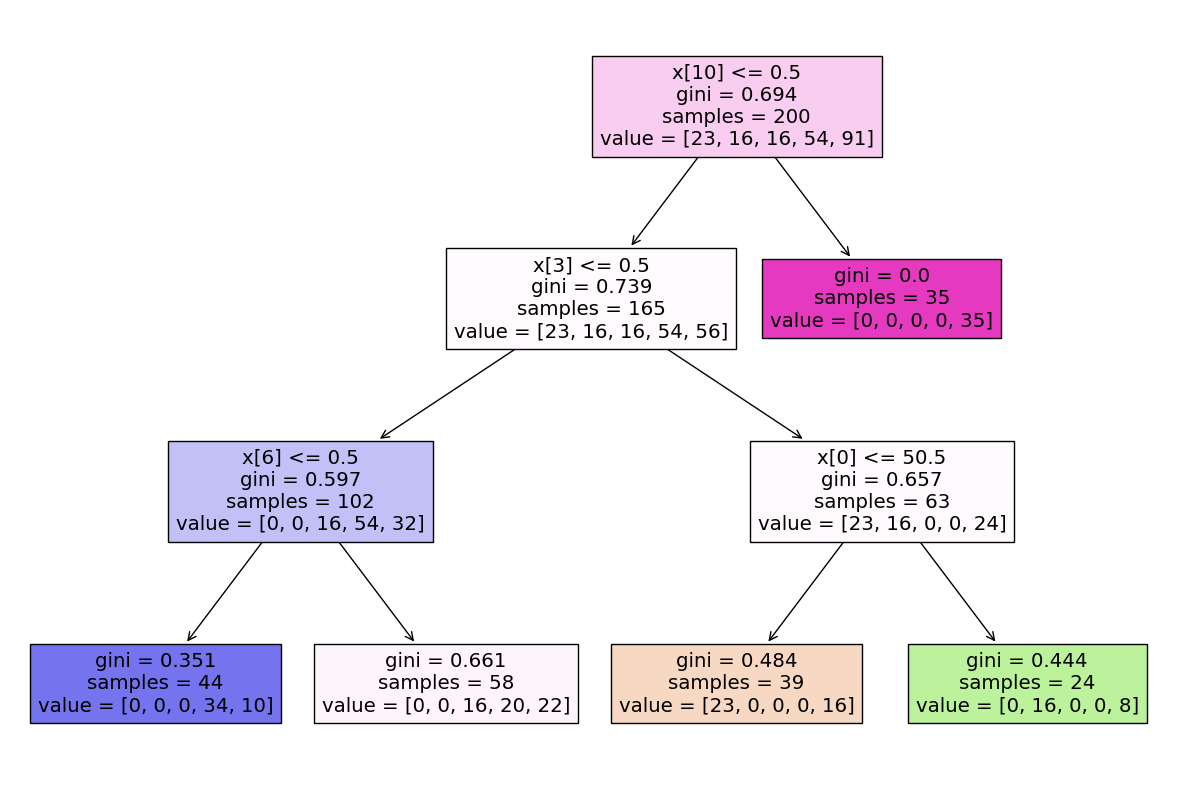

In [197]:
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)

In [198]:
print(tree.export_text(classifier))

|--- feature_10 <= 0.50
|   |--- feature_3 <= 0.50
|   |   |--- feature_6 <= 0.50
|   |   |   |--- class: drugX
|   |   |--- feature_6 >  0.50
|   |   |   |--- class: drugY
|   |--- feature_3 >  0.50
|   |   |--- feature_0 <= 50.50
|   |   |   |--- class: drugA
|   |   |--- feature_0 >  50.50
|   |   |   |--- class: drugB
|--- feature_10 >  0.50
|   |--- class: drugY



#### Model evaluation level=3

In [199]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import numpy as np
score = accuracy_score(y_test, y_pred)
print(score)

0.6428571428571429


#### Making the Confusion Matrix at level=3

In [200]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[2 0 0 0 0]
 [0 3 0 0 0]
 [0 0 0 0 2]
 [0 0 0 3 1]
 [0 1 0 1 1]]
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         2
       drugB       0.75      1.00      0.86         3
       drugC       0.00      0.00      0.00         2
       drugX       0.75      0.75      0.75         4
       drugY       0.25      0.33      0.29         3

    accuracy                           0.64        14
   macro avg       0.55      0.62      0.58        14
weighted avg       0.57      0.64      0.60        14



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Tree Construct here. At here level = 6

In [201]:
from sklearn import tree
classifier = tree.DecisionTreeClassifier(max_depth = 6, criterion = 'gini', random_state = 0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

[Text(0.54, 0.9285714285714286, 'x[10] <= 0.5\ngini = 0.694\nsamples = 200\nvalue = [23, 16, 16, 54, 91]'),
 Text(0.5, 0.7857142857142857, 'x[3] <= 0.5\ngini = 0.739\nsamples = 165\nvalue = [23, 16, 16, 54, 56]'),
 Text(0.26, 0.6428571428571429, 'x[6] <= 0.5\ngini = 0.597\nsamples = 102\nvalue = [0, 0, 16, 54, 32]'),
 Text(0.12, 0.5, 'x[11] <= 0.5\ngini = 0.351\nsamples = 44\nvalue = [0, 0, 0, 34, 10]'),
 Text(0.08, 0.35714285714285715, 'x[9] <= 0.5\ngini = 0.283\nsamples = 41\nvalue = [0, 0, 0, 34, 7]'),
 Text(0.04, 0.21428571428571427, 'gini = 0.0\nsamples = 14\nvalue = [0, 0, 0, 14, 0]'),
 Text(0.12, 0.21428571428571427, 'x[0] <= 36.5\ngini = 0.384\nsamples = 27\nvalue = [0, 0, 0, 20, 7]'),
 Text(0.08, 0.07142857142857142, 'gini = 0.0\nsamples = 6\nvalue = [0, 0, 0, 6, 0]'),
 Text(0.16, 0.07142857142857142, 'gini = 0.444\nsamples = 21\nvalue = [0, 0, 0, 14, 7]'),
 Text(0.16, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 0, 0, 3]'),
 Text(0.4, 0.5, 'x[5] <= 0.5\ngini 

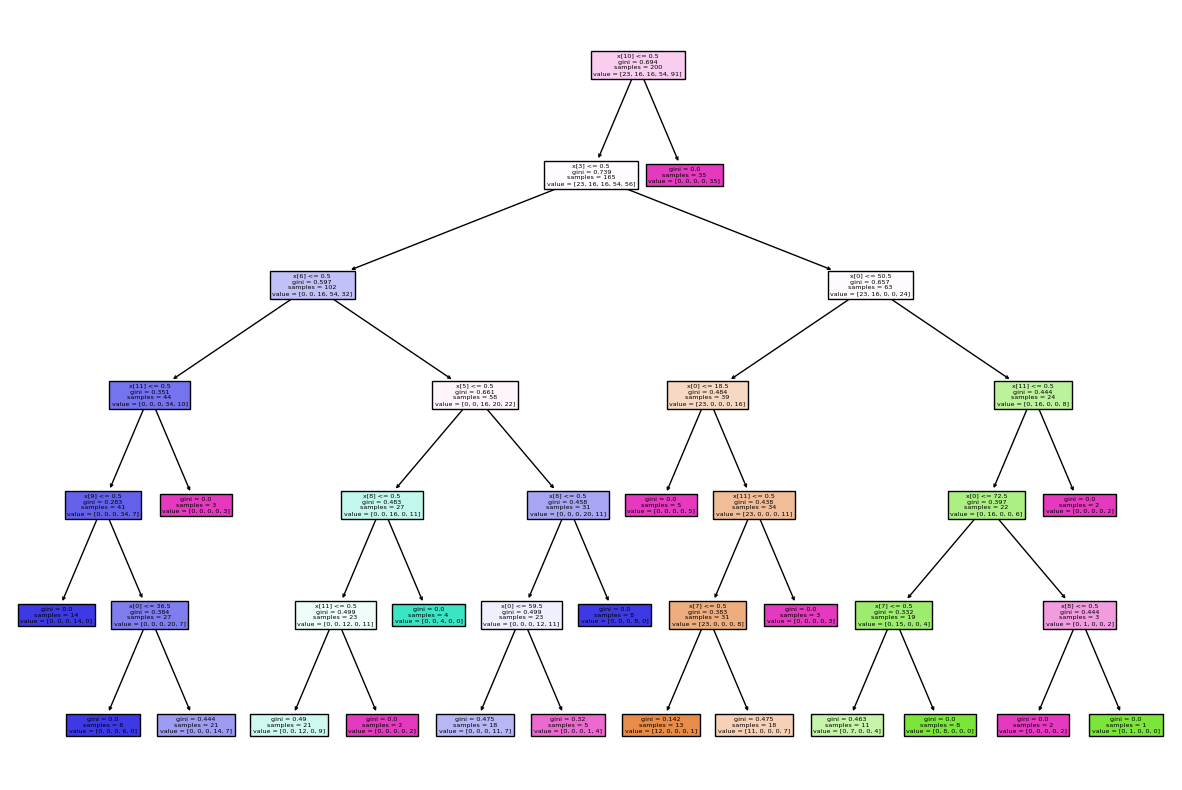

In [202]:
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)

In [203]:
print(tree.export_text(classifier))

|--- feature_10 <= 0.50
|   |--- feature_3 <= 0.50
|   |   |--- feature_6 <= 0.50
|   |   |   |--- feature_11 <= 0.50
|   |   |   |   |--- feature_9 <= 0.50
|   |   |   |   |   |--- class: drugX
|   |   |   |   |--- feature_9 >  0.50
|   |   |   |   |   |--- feature_0 <= 36.50
|   |   |   |   |   |   |--- class: drugX
|   |   |   |   |   |--- feature_0 >  36.50
|   |   |   |   |   |   |--- class: drugX
|   |   |   |--- feature_11 >  0.50
|   |   |   |   |--- class: drugY
|   |   |--- feature_6 >  0.50
|   |   |   |--- feature_5 <= 0.50
|   |   |   |   |--- feature_8 <= 0.50
|   |   |   |   |   |--- feature_11 <= 0.50
|   |   |   |   |   |   |--- class: drugC
|   |   |   |   |   |--- feature_11 >  0.50
|   |   |   |   |   |   |--- class: drugY
|   |   |   |   |--- feature_8 >  0.50
|   |   |   |   |   |--- class: drugC
|   |   |   |--- feature_5 >  0.50
|   |   |   |   |--- feature_8 <= 0.50
|   |   |   |   |   |--- feature_0 <= 59.50
|   |   |   |   |   |   |--- class: drugX
|   |   | 

#### Model evaluation level=6

In [204]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import numpy as np
score = accuracy_score(y_test, y_pred)
print(score)

0.9285714285714286


#### Making the Confusion Matrix at level=6

In [205]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[2 0 0 0 0]
 [0 3 0 0 0]
 [0 0 2 0 0]
 [0 0 0 4 0]
 [0 0 0 1 2]]
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         2
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         2
       drugX       0.80      1.00      0.89         4
       drugY       1.00      0.67      0.80         3

    accuracy                           0.93        14
   macro avg       0.96      0.93      0.94        14
weighted avg       0.94      0.93      0.93        14



### Prediction of Unseen

In [206]:
from sklearn.tree import DecisionTreeClassifier

In [207]:
drug_unseen

,AGE,SEX,BP,CHOLES,DRUG,NA_to_K
0,57,M,LOW,NORMAL,NaN,Medium
1,49,F,NORMAL,NORMAL,NaN,Low
2,74,M,HIGH,HIGH,NaN,Low
3,49,M,LOW,NORMAL,NaN,Medium
4,65,F,HIGH,NORMAL,NaN,VeryHigh
5,53,M,NORMAL,HIGH,NaN,Medium
6,32,M,HIGH,NORMAL,NaN,Low
7,68,M,LOW,HIGH,NaN,Medium
8,68,F,HIGH,NORMAL,NaN,Medium
9,26,F,LOW,HIGH,NaN,Medium


In [208]:
drug_unseen_encoded = pd.get_dummies(drug_unseen, columns=['SEX', 'BP', 'CHOLES', 'NA_to_K'])

In [209]:
drug_unseen_encoded

,AGE,DRUG,SEX_F,SEX_M,BP_HIGH,BP_LOW,BP_NORMAL,CHOLES_HIGH,CHOLES_NORMAL,NA_to_K_Low,NA_to_K_Medium,NA_to_K_High,NA_to_K_VeryHigh
0,57,NaN,0,1,0,1,0,0,1,0,1,0,0
1,49,NaN,1,0,0,0,1,0,1,1,0,0,0
2,74,NaN,0,1,1,0,0,1,0,1,0,0,0
3,49,NaN,0,1,0,1,0,0,1,0,1,0,0
4,65,NaN,1,0,1,0,0,0,1,0,0,0,1
5,53,NaN,0,1,0,0,1,1,0,0,1,0,0
6,32,NaN,0,1,1,0,0,0,1,1,0,0,0
7,68,NaN,0,1,0,1,0,1,0,0,1,0,0
8,68,NaN,1,0,1,0,0,0,1,0,1,0,0
9,26,NaN,1,0,0,1,0,1,0,0,1,0,0


In [210]:
clf = DecisionTreeClassifier(random_state=1992)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1992)

In [211]:
drug_unseen_encoded = drug_unseen_encoded.drop(columns=['DRUG'])

In [212]:
predictions = clf.predict(drug_unseen_encoded)

In [213]:
predictions

array(['drugY', 'drugX', 'drugB', 'drugX', 'drugY', 'drugX', 'drugA',
       'drugC', 'drugB', 'drugC', 'drugA', 'drugY', 'drugX', 'drugB'],
      dtype=object)

In [214]:
drug_unseen_encoded['drug_predict'] = predictions

In [215]:
drug_unseen_encoded

,AGE,SEX_F,SEX_M,BP_HIGH,BP_LOW,BP_NORMAL,CHOLES_HIGH,CHOLES_NORMAL,NA_to_K_Low,NA_to_K_Medium,NA_to_K_High,NA_to_K_VeryHigh,drug_predict
0,57,0,1,0,1,0,0,1,0,1,0,0,drugY
1,49,1,0,0,0,1,0,1,1,0,0,0,drugX
2,74,0,1,1,0,0,1,0,1,0,0,0,drugB
3,49,0,1,0,1,0,0,1,0,1,0,0,drugX
4,65,1,0,1,0,0,0,1,0,0,0,1,drugY
5,53,0,1,0,0,1,1,0,0,1,0,0,drugX
6,32,0,1,1,0,0,0,1,1,0,0,0,drugA
7,68,0,1,0,1,0,1,0,0,1,0,0,drugC
8,68,1,0,1,0,0,0,1,0,1,0,0,drugB
9,26,1,0,0,1,0,1,0,0,1,0,0,drugC
